## 1) Setup & Paths

Framework used in this notebook:
- Isotropic region radius: $r=\sigma$
- Manifold axes: $a_i = \sigma\sqrt{\tilde\lambda_i}$ with $\tilde\lambda_i = \lambda_i / \lambda_{max}$
- Compare methods from saved `metrics.json` and `eigenvalues.npz`

In [3]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.certify.randomized import normalize_eigenvalues, axis_lengths
from src.indexing.base import build_index, query_index
from src.indexing.image_index import load_image_index_artifacts
from src.smoothing.pca import fit_local_pca

DATASET = "celeba"
BASE = repo_root / "output" / "smile_classification" / DATASET
CERTIFY_DIR = BASE / "certify"
PIXEL_INDEX_DIR = BASE / "index" / "pixel" / "annoy" / "euclidean"
LATENT_INDEX_DIR = BASE / "index" / "latent" / "annoy" / "euclidean"

MODES = ["pixel_isotropic", "pixel_manifold", "latent_isotropic", "latent_manifold"]
# SIGMAS_ALL = [
#     "sigma_0_10",
#     "sigma_0_12",
#     "sigma_0_14",
#     "sigma_0_16",
#     "sigma_0_18",
#     "sigma_0_20",
#     "sigma_0_22",
#     "sigma_0_24"
# ]

SIGMAS_ALL = [
    "sigma_0_01",
    "sigma_0_03",
    "sigma_0_05",
    "sigma_0_07",
    "sigma_0_10",
    "sigma_0_12",
    "sigma_0_15",
    "sigma_0_17",
    "sigma_0_20",
    "sigma_0_22",
    "sigma_0_25",
    "sigma_0_27",
    "sigma_0_30",
    "sigma_0_32",
    "sigma_0_35",
    "sigma_0_37",
    "sigma_0_40",
    "sigma_0_42",
    "sigma_0_45",
    "sigma_0_47",
    "sigma_0_50",
    "sigma_0_55",
]
def sigma_val(s: str) -> float:
    return float(s.replace("sigma_", "").replace("_", "."))

def mode_label(mode: str) -> str:
    return mode.replace("_", " " ).title()

def load_metrics(folder: Path):
    if not folder.exists():
        return None
    for name in ["metrics.json", "running_metrics.json"]:
        p = folder / name
        if p.exists():
            with open(p, "r", encoding="utf-8") as f:
                data = json.load(f)
            if name == "running_metrics.json":
                return {"_status": "running", "_raw": data}
            return data
    return None

print("Setup complete")
print("repo_root:", repo_root)
print("certify_dir:", CERTIFY_DIR)
print("pixel_index_dir exists:", PIXEL_INDEX_DIR.exists())
print("latent_index_dir exists:", LATENT_INDEX_DIR.exists())

Setup complete
repo_root: /BS/dniazi_thesis/work/RandomizedSmothingmanifold
certify_dir: /BS/dniazi_thesis/work/RandomizedSmothingmanifold/output/smile_classification/celeba/certify
pixel_index_dir exists: True
latent_index_dir exists: True


## 2) Isotropic vs Manifold (from job metrics)

,space,smoothing,sigma,certified_acc,abstain_rate,mean_radius,median_radius,certified_correct,smile_acc,no_smile_acc
0,Pixel,Isotropic,0.10,0.72,0.02,0.1392,0.1500,72,0.4909,1.0000
1,Pixel,Isotropic,0.15,0.47,0.00,0.2163,0.2251,47,0.0364,1.0000
2,Pixel,Isotropic,0.20,0.45,0.00,0.3001,0.3001,45,0.0000,1.0000
3,Pixel,Isotropic,0.25,0.45,0.00,0.3751,0.3751,45,0.0000,1.0000
4,Pixel,Isotropic,0.30,0.45,0.00,0.4501,0.4501,45,0.0000,1.0000
5,Pixel,Isotropic,0.35,0.45,0.00,0.5252,0.5252,45,0.0000,1.0000
6,Pixel,Isotropic,0.40,0.45,0.00,0.6002,0.6002,45,0.0000,1.0000
7,Pixel,Isotropic,0.45,0.45,0.00,0.6752,0.6752,45,0.0000,1.0000
8,Pixel,Isotropic,0.50,0.45,0.00,0.7502,0.7502,45,0.0000,1.0000
9,Pixel,Isotropic,0.55,0.45,0.00,0.8253,0.8253,45,0.0000,1.0000


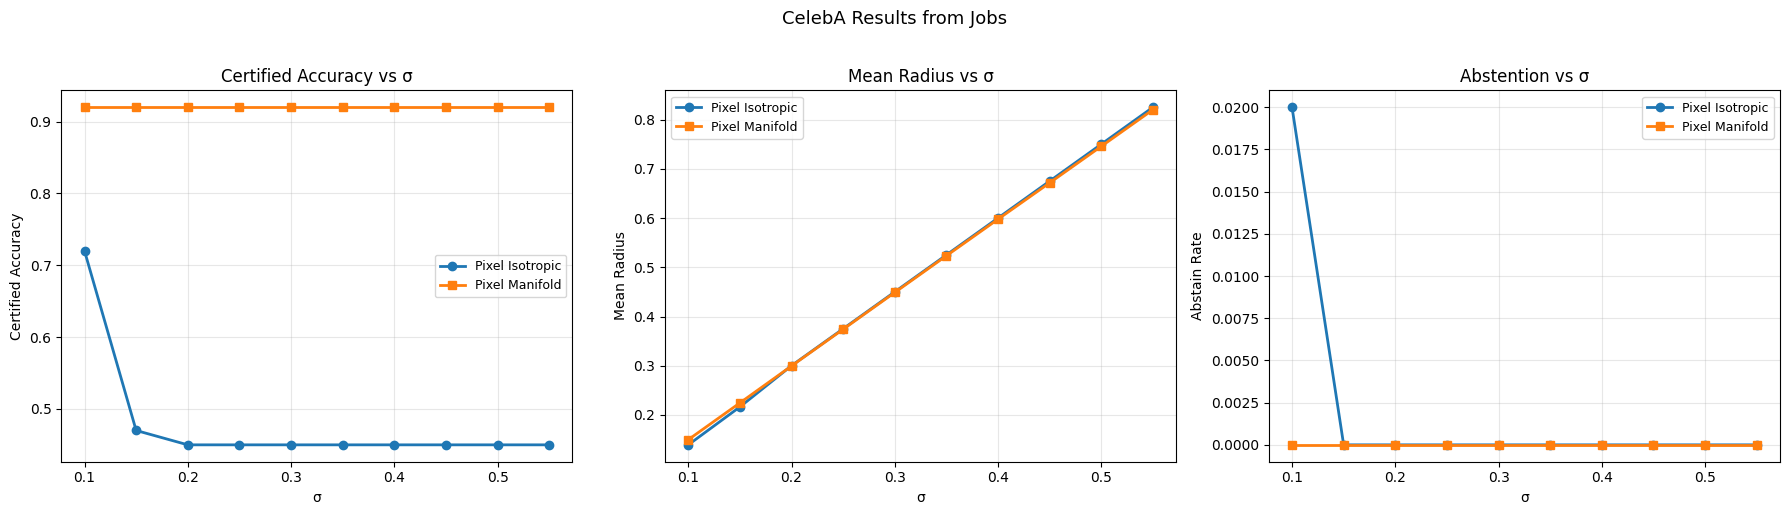

In [4]:
rows = []
for mode in MODES:
    for sig in SIGMAS_ALL:
        m = load_metrics(CERTIFY_DIR / mode / sig)
        if m is None or m.get("_status") == "running":
            continue

        vol = m.get('volume', {}) if isinstance(m, dict) else {}
        geo = vol.get('geometry', {}) if isinstance(vol, dict) else {}
        
        rows.append({
            # "mode": mode_label(mode),
            "space": mode.split("_")[0].title(),
            "smoothing": mode.split("_")[1].title(),
            "sigma": sigma_val(sig),
            "certified_acc": m.get("certified_accuracy", np.nan),
            "abstain_rate": m.get("abstain_rate", np.nan),
            "mean_radius": m.get("mean_radius", np.nan),
            "median_radius": m.get("median_radius", np.nan),
            "certified_correct": m.get("certified_correct", np.nan),
            # "total": m.get("total_test_samples", np.nan),
            "smile_acc": m.get("class_smile_accuracy", np.nan),
            "no_smile_acc": m.get("class_no_smile_accuracy", np.nan),
        })

if not rows:
    print("No completed CelebA metrics found yet.")
else:
    df = pd.DataFrame(rows).sort_values([ "smoothing", "sigma"])
    display(df.round(4))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for space in ["Pixel", "Latent"]:
        for smooth, style in [("Isotropic", "o-"), ("Manifold", "s-")]:
            sub = df[(df["space"] == space) & (df["smoothing"] == smooth)].sort_values("sigma")
            if sub.empty:
                continue
            label = f"{space} {smooth}"
            axes[0].plot(sub["sigma"], sub["certified_acc"], style, linewidth=2, label=label)
            axes[1].plot(sub["sigma"], sub["mean_radius"], style, linewidth=2, label=label)
            axes[2].plot(sub["sigma"], sub["abstain_rate"], style, linewidth=2, label=label)

    axes[0].set_title("Certified Accuracy vs σ")
    axes[1].set_title("Mean Radius vs σ")
    axes[2].set_title("Abstention vs σ")
    axes[0].set_ylabel("Certified Accuracy")
    axes[1].set_ylabel("Mean Radius")
    axes[2].set_ylabel("Abstain Rate")
    for ax in axes:
        ax.set_xlabel("σ")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=9)
    plt.suptitle("CelebA Results from Jobs", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

## 3) Same Accuracy Matching (Manifold vs Isotropic)

,space,target_acc,sigma_mani,sigma_iso_closest,abs_gap
0,Pixel,0.92,0.01,0.05,0.0033
1,Pixel,0.92,0.03,0.05,0.0033
2,Pixel,0.92,0.05,0.05,0.0033
3,Pixel,0.92,0.07,0.05,0.0033
4,Pixel,0.92,0.10,0.05,0.0033
5,Pixel,0.92,0.12,0.05,0.0033
6,Pixel,0.92,0.15,0.05,0.0033
7,Pixel,0.92,0.17,0.05,0.0033
8,Pixel,0.92,0.20,0.05,0.0033
9,Pixel,0.92,0.22,0.05,0.0033


/tmp/ipykernel_2239411/4185131798.py:74: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax1.legend(fontsize=8)


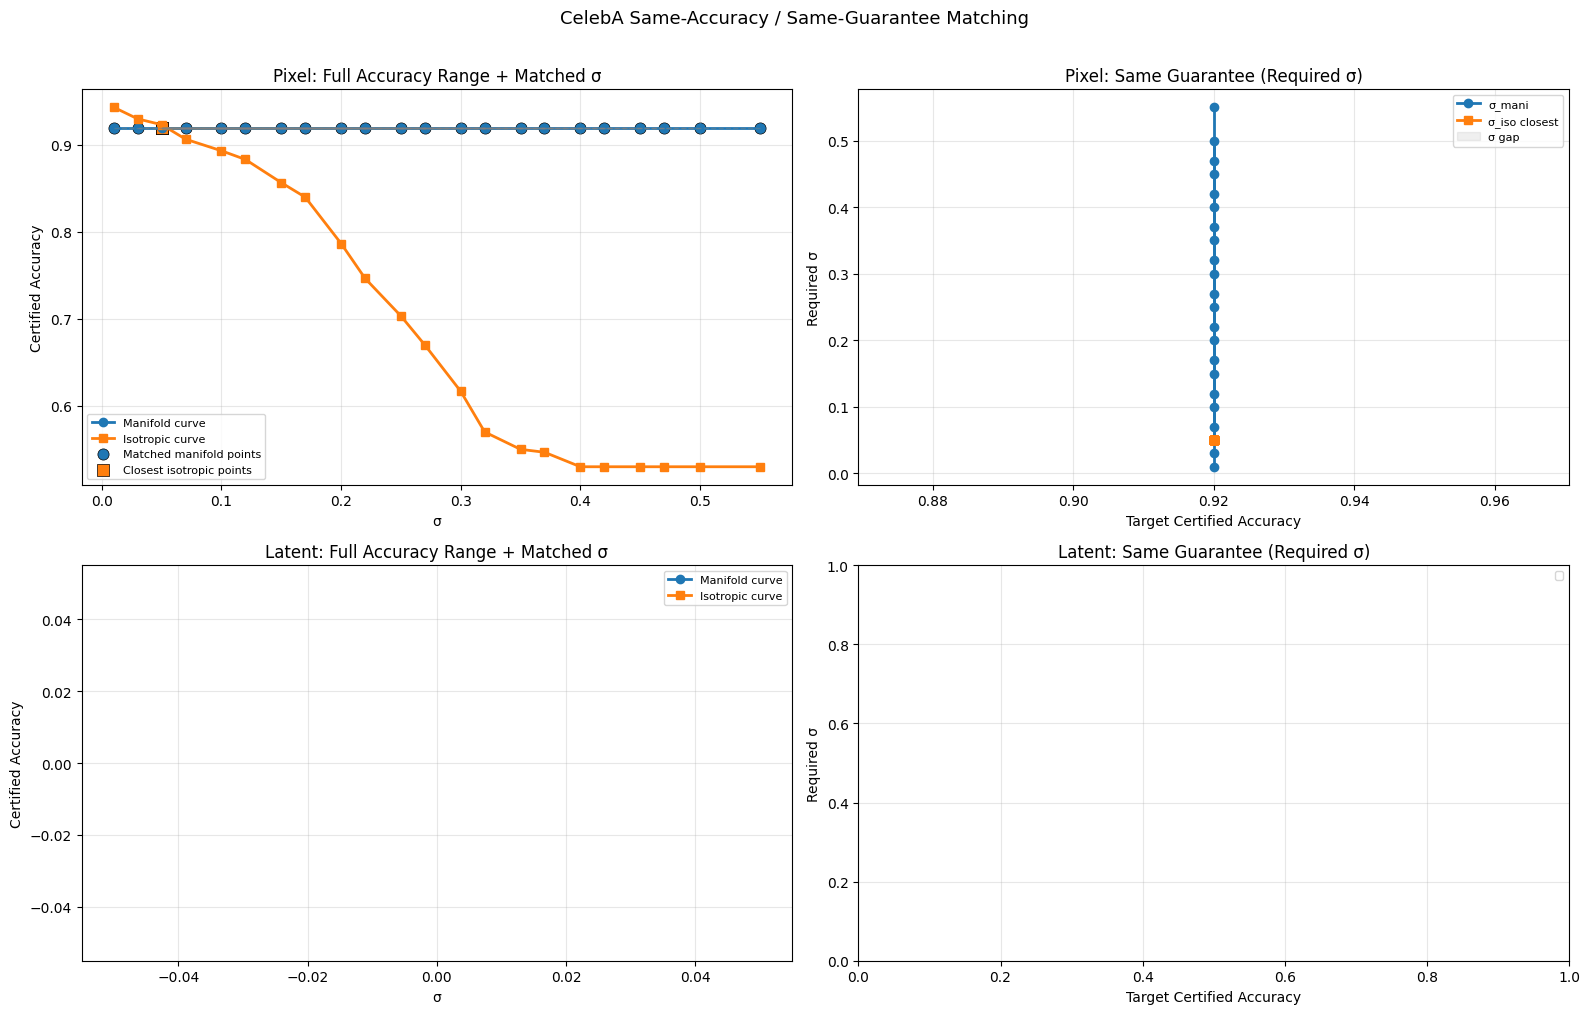

Interpretation:
- Left panels: full accuracy curves for manifold and isotropic, with matched sigma points highlighted.
- Right panels: for each target accuracy, compare required sigma in manifold vs isotropic.
- If sigma_mani < sigma_iso_closest, manifold reaches the same guarantee with less noise.


In [3]:
if "df" not in globals() or df.empty:
    print("Run Section 2 first.")
else:
    all_matches = []
    for space in ["Pixel", "Latent"]:
        mani = df[(df["space"] == space) & (df["smoothing"] == "Manifold")].sort_values("sigma")
        iso = df[(df["space"] == space) & (df["smoothing"] == "Isotropic")].sort_values("sigma")
        if mani.empty or iso.empty:
            continue

        for _, mrow in mani.iterrows():
            idx = (iso["certified_acc"] - mrow["certified_acc"]).abs().idxmin()
            irow = iso.loc[idx]
            all_matches.append({
                "space": space,
                "target_acc": float(mrow["certified_acc"]),
                "sigma_mani": float(mrow["sigma"]),
                "sigma_iso_closest": float(irow["sigma"]),
                "abs_gap": float(abs(mrow["certified_acc"] - irow["certified_acc"])),
            })

    if not all_matches:
        print("No manifold/isotropic pairs found for matching.")
    else:
        df_match = pd.DataFrame(all_matches).sort_values(["space", "target_acc"], ascending=[True, False])
        display(df_match.round(4))

        fig, axes = plt.subplots(2, 2, figsize=(16, 10))

        for row_i, space in enumerate(["Pixel", "Latent"]):
            sub_match = df_match[df_match["space"] == space].sort_values("target_acc", ascending=False)
            mani = df[(df["space"] == space) & (df["smoothing"] == "Manifold")].sort_values("sigma")
            iso = df[(df["space"] == space) & (df["smoothing"] == "Isotropic")].sort_values("sigma")

            # Left column: full curves + matched points
            ax0 = axes[row_i, 0]
            ax0.plot(mani["sigma"], mani["certified_acc"], "o-", color="tab:blue", linewidth=2, label="Manifold curve")
            ax0.plot(iso["sigma"], iso["certified_acc"], "s-", color="tab:orange", linewidth=2, label="Isotropic curve")

            if not sub_match.empty:
                ax0.scatter(sub_match["sigma_mani"], sub_match["target_acc"],
                            c="tab:blue", s=65, marker="o", edgecolors="black", linewidths=0.5,
                            label="Matched manifold points")
                ax0.scatter(sub_match["sigma_iso_closest"], sub_match["target_acc"],
                            c="tab:orange", s=65, marker="s", edgecolors="black", linewidths=0.5,
                            label="Closest isotropic points")

                for _, r in sub_match.iterrows():
                    y = r["target_acc"]
                    xm, xi = r["sigma_mani"], r["sigma_iso_closest"]
                    ax0.plot([xm, xi], [y, y], linestyle="--", linewidth=1.0, color="gray", alpha=0.45)

            ax0.set_title(f"{space}: Full Accuracy Range + Matched σ")
            ax0.set_xlabel("σ")
            ax0.set_ylabel("Certified Accuracy")
            ax0.grid(True, alpha=0.3)
            ax0.legend(fontsize=8)

            # Right column: required sigma at matched target accuracy
            ax1 = axes[row_i, 1]
            if not sub_match.empty:
                ax1.plot(sub_match["target_acc"], sub_match["sigma_mani"], "o-", label="σ_mani", color="tab:blue", linewidth=2)
                ax1.plot(sub_match["target_acc"], sub_match["sigma_iso_closest"], "s-", label="σ_iso closest", color="tab:orange", linewidth=2)
                ax1.fill_between(
                    sub_match["target_acc"],
                    sub_match["sigma_mani"],
                    sub_match["sigma_iso_closest"],
                    color="gray", alpha=0.12, label="σ gap"
                )
            ax1.set_title(f"{space}: Same Guarantee (Required σ)")
            ax1.set_xlabel("Target Certified Accuracy")
            ax1.set_ylabel("Required σ")
            ax1.grid(True, alpha=0.3)
            ax1.legend(fontsize=8)

        plt.suptitle("CelebA Same-Accuracy / Same-Guarantee Matching", fontsize=13, y=1.01)
        plt.tight_layout()
        plt.show()

        print("Interpretation:")
        print("- Left panels: full accuracy curves for manifold and isotropic, with matched sigma points highlighted.")
        print("- Right panels: for each target accuracy, compare required sigma in manifold vs isotropic.")
        print("- If sigma_mani < sigma_iso_closest, manifold reaches the same guarantee with less noise.")

## 4) New Volume Geometry Metrics from `metrics.json`

Reads `volume.geometry` when present, with fallback to legacy `volume` keys.

,mode,space,sigma,mean_log_geo_ratio,mean_anisotropy_ratio,mean_effective_rank,log_v_iso_geo,mean_log_v_mani_geo
0,Pixel Manifold,Pixel,0.01,-1268.408,67401.5978,100.1689,-3150.4479,-4418.8558
1,Pixel Manifold,Pixel,0.03,-1268.408,67401.5978,100.1689,-2601.1417,-3869.5497
2,Pixel Manifold,Pixel,0.05,-1268.408,67401.5978,100.1689,-2345.7289,-3614.1369
3,Pixel Manifold,Pixel,0.07,-1268.408,67401.5978,100.1689,-2177.4928,-3445.9007
4,Pixel Manifold,Pixel,0.10,-1268.408,67401.5978,100.1689,-1999.1553,-3267.5633
5,Pixel Manifold,Pixel,0.12,-1268.408,67401.5978,100.1689,-1907.9945,-3176.4025
6,Pixel Manifold,Pixel,0.15,-1268.408,67401.5978,100.1689,-1796.4228,-3064.8307
7,Pixel Manifold,Pixel,0.17,-1268.408,67401.5978,100.1689,-1733.8412,-3002.2491
8,Pixel Manifold,Pixel,0.20,-1268.408,67401.5978,100.1689,-1652.5817,-2920.9897
9,Pixel Manifold,Pixel,0.22,-1268.408,67401.5978,100.1689,-1604.9266,-2873.3346


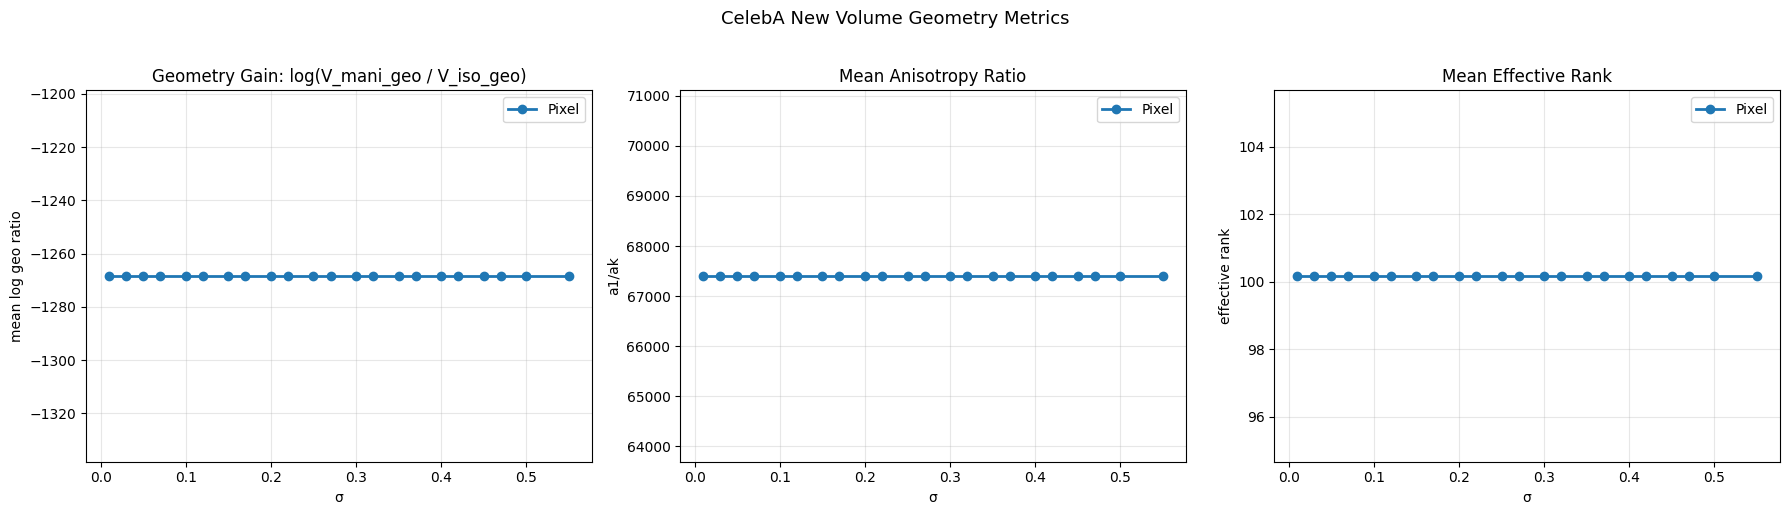

In [4]:
vol_rows = []
for mode in ["pixel_manifold", "latent_manifold"]:
    for sig in SIGMAS_ALL:
        m = load_metrics(CERTIFY_DIR / mode / sig)
        if m is None or m.get("_status") == "running":
            continue
        vol = m.get("volume", {}) if isinstance(m, dict) else {}
        geo = vol.get("geometry", {}) if isinstance(vol, dict) else {}
        vol_rows.append({
            "mode": mode_label(mode),
            "space": mode.split("_")[0].title(),
            "sigma": sigma_val(sig),
            "mean_log_geo_ratio": geo.get("mean_log_geo_ratio", vol.get("mean_geometry_factor", np.nan)),
            "mean_anisotropy_ratio": geo.get("mean_anisotropy_ratio", np.nan),
            "mean_effective_rank": geo.get("mean_effective_rank", vol.get("mean_effective_rank", np.nan)),
            "log_v_iso_geo": geo.get("log_v_iso_geo", np.nan),
            "mean_log_v_mani_geo": geo.get("mean_log_v_mani_geo_max_norm", geo.get("mean_log_v_mani_geo", np.nan)),
        })

if not vol_rows:
    print("No volume geometry metrics found.")
else:
    df_geo = pd.DataFrame(vol_rows).sort_values(["space", "sigma"])
    display(df_geo.round(4))

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for space in ["Pixel", "Latent"]:
        sub = df_geo[df_geo["space"] == space].sort_values("sigma")
        if sub.empty:
            continue
        axes[0].plot(sub["sigma"], sub["mean_log_geo_ratio"], "o-", linewidth=2, label=space)
        axes[1].plot(sub["sigma"], sub["mean_anisotropy_ratio"], "o-", linewidth=2, label=space)
        axes[2].plot(sub["sigma"], sub["mean_effective_rank"], "o-", linewidth=2, label=space)

    axes[0].set_title("Geometry Gain: log(V_mani_geo / V_iso_geo)")
    axes[1].set_title("Mean Anisotropy Ratio")
    axes[2].set_title("Mean Effective Rank")
    axes[0].set_ylabel("mean log geo ratio")
    axes[1].set_ylabel("a1/ak")
    axes[2].set_ylabel("effective rank")
    for ax in axes:
        ax.set_xlabel("σ")
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.suptitle("CelebA New Volume Geometry Metrics", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

## 5) Full Eigen / Axis Spectrum from `eigenvalues.npz`

Reads full arrays such as `axis_lengths_all`, with fallback to legacy keys.

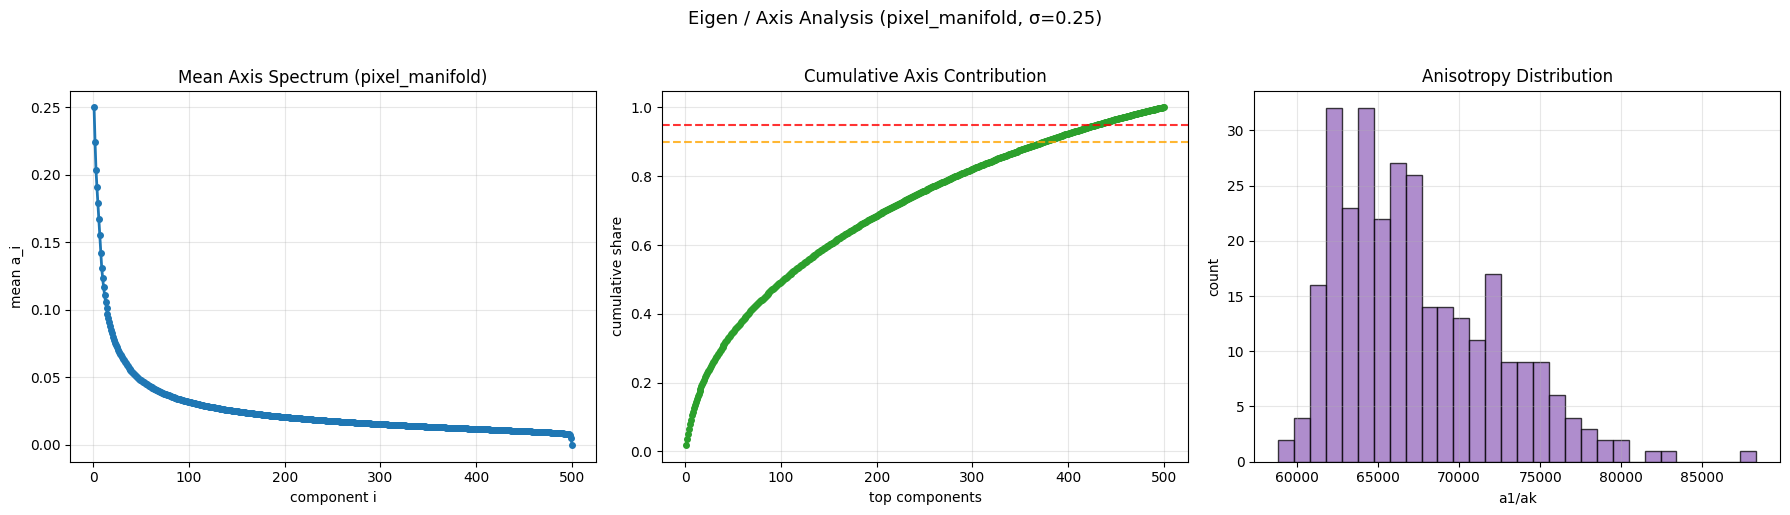

Loaded: /BS/dniazi_thesis/work/RandomizedSmothingmanifold/output/smile_classification/celeba/certify_completeds/pixel_manifold/sigma_0_25/eigenvalues.npz
axis_arr shape: (300, 500)
No eigenvalues file at /BS/dniazi_thesis/work/RandomizedSmothingmanifold/output/smile_classification/celeba/certify_completeds/latent_manifold/sigma_0_25/eigenvalues.npz


In [5]:
TARGET_SIGMA = "sigma_0_25"
for mode in ["pixel_manifold", "latent_manifold"]:
    eigen_path = CERTIFY_DIR / mode / TARGET_SIGMA / "eigenvalues.npz"
    if not eigen_path.exists():
        print(f"No eigenvalues file at {eigen_path}")
        continue

    data = np.load(eigen_path)
    axis_arr = data.get("axis_lengths_all", data.get("axis_lengths_top10", None))
    anis = data.get("anisotropy_ratios", None)
    geo_ratio = data.get("log_geo_ratio_per_sample", data.get("log_geo_ratio_per_token", None))

    if axis_arr is None:
        print(f"Axis arrays not found in {eigen_path}")
        continue

    axis_arr = np.asarray(axis_arr, dtype=np.float64)
    mean_axes = np.nanmean(axis_arr, axis=0)
    cum = np.cumsum(np.maximum(mean_axes, 0.0))
    if len(cum) > 0 and cum[-1] > 0:
        cum = cum / cum[-1]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].plot(np.arange(1, len(mean_axes) + 1), mean_axes, "o-", linewidth=2, markersize=4)
    axes[0].set_title(f"Mean Axis Spectrum ({mode})")
    axes[0].set_xlabel("component i")
    axes[0].set_ylabel("mean a_i")
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(np.arange(1, len(cum) + 1), cum, "o-", linewidth=2, markersize=4, color="tab:green")
    axes[1].axhline(0.9, linestyle="--", color="orange", alpha=0.8)
    axes[1].axhline(0.95, linestyle="--", color="red", alpha=0.8)
    axes[1].set_title("Cumulative Axis Contribution")
    axes[1].set_xlabel("top components")
    axes[1].set_ylabel("cumulative share")
    axes[1].grid(True, alpha=0.3)

    if anis is not None:
        axes[2].hist(np.asarray(anis, dtype=np.float64), bins=30, color="tab:purple", alpha=0.75, edgecolor="black")
        axes[2].set_title("Anisotropy Distribution")
        axes[2].set_xlabel("a1/ak")
    elif geo_ratio is not None:
        axes[2].hist(np.asarray(geo_ratio, dtype=np.float64), bins=30, color="tab:red", alpha=0.75, edgecolor="black")
        axes[2].set_title("Geometry Gain Distribution")
        axes[2].set_xlabel("log geo ratio")
    else:
        axes[2].text(0.5, 0.5, "No anisotropy/geo arrays", ha="center", va="center")
    axes[2].set_ylabel("count")
    axes[2].grid(True, alpha=0.3)

    plt.suptitle(f"Eigen / Axis Analysis ({mode}, σ={sigma_val(TARGET_SIGMA)})", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()

    print("Loaded:", eigen_path)
    print("axis_arr shape:", axis_arr.shape)

## 6) Embedding Neighborhood: Circle vs Ellipse

Local PCA geometry interpretation on index vectors:
- Blue circle: isotropic region, radius $r=\sigma$
- Green ellipse: manifold region with axes $a_i = \sigma\sqrt{\tilde\lambda_i}$

In [7]:

# ── Config ───────────────────────────────────────────────────────────────────
SPACE       = "pixel"            # "pixel" or "latent"
SIGMAS      = [0.10, 0.20, 0.30] # three sigma values overlaid per sample
knn_k       = 250                # safer than 500 in high-dimensional pixel space
N_SAMPLES   = 3                  # keep a few anchors so the kernel stays stable
ANCHOR_IDXS = list(range(N_SAMPLES))
MANUAL_DIM  = 150528             # override if metadata is missing
PCA_COMPONENTS_ANALYSIS = 2     # retain top-10 eigen-directions for semantic-axis analysis

# ── Style ─────────────────────────────────────────────────────────────────────
SIGMA_PALETTE   = ["#2166ac", "#d6604d", "#4dac26"]
SIGMA_ALPHA     = [0.95, 0.90, 0.85]
SIGMA_LW        = 1.6
SCATTER_COLOR   = "#d0d0d0"
ANCHOR_COLOR    = "#f5c518"
FONT_MAIN       = {"family": "serif", "size": 9}
plt.rcParams.update({
    'font.family':        'serif',
    'font.size':          11,
    'axes.titlesize':     12,
    'axes.labelsize':     11,
    'xtick.labelsize':    9,
    'ytick.labelsize':    9,
    'legend.fontsize':    9,
    'figure.facecolor':   'white',
    'axes.facecolor':     'white',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.grid':          True,
    'grid.alpha':         0.25,
    'grid.linestyle':     '--',
    'lines.linewidth':    2.0,
    'lines.markersize':   5,
    'savefig.dpi':        150,
    'savefig.bbox':       'tight',
})

# ── Load index ────────────────────────────────────────────────────────────────
from sklearn.decomposition import PCA
from src.indexing.base import load_index

index_dir  = LATENT_INDEX_DIR if SPACE == "latent" else PIXEL_INDEX_DIR
index_path = index_dir / "index.ann"
if not index_dir.exists():
    raise FileNotFoundError(f"Index directory not found: {index_dir}")
if not index_path.exists():
    raise FileNotFoundError(f"Annoy index not found: {index_path}")

dim = MANUAL_DIM
if dim is None:
    for meta_name in ["metadata.json", "image_metadata.json"]:
        mp = index_dir / meta_name
        if mp.exists():
            with open(mp) as f:
                _m = json.load(f)
            dim = int(_m.get("dim", _m.get("vector_dim", 0)) or 0)
            if dim > 0:
                break
if not dim:
    raise ValueError("Could not determine index dimension. Set MANUAL_DIM.")

annoy_idx = load_index(dim, index_path, backend="annoy")
n_items   = annoy_idx.index.get_n_items()
ANCHOR_IDXS = [i for i in ANCHOR_IDXS if i < n_items]
if not ANCHOR_IDXS:
    raise ValueError("All anchor indices are out of range.")

# ── Pre-compute PCA (once per sample, reused across sigmas) ──────────────────
# Safer path: use float32 + limited anchors/neighbours and compute top-10 components.
# The 2D plot uses only PC1/PC2, while the top-10 eigenvalues are kept for analysis.
sample_data = {}
for anchor_idx in ANCHOR_IDXS:
    av = np.asarray(annoy_idx.index.get_item_vector(anchor_idx), dtype=np.float32)
    ids = annoy_idx.index.get_nns_by_item(anchor_idx, knn_k + 1, include_distances=False)
    nids = [i for i in ids if i != anchor_idx][:knn_k]
    nvecs = np.asarray([annoy_idx.index.get_item_vector(int(i)) for i in nids], dtype=np.float32)

    local_mean = nvecs.mean(axis=0, dtype=np.float32)
    centered = nvecs - local_mean

    n_components = int(min(PCA_COMPONENTS_ANALYSIS, centered.shape[0], centered.shape[1]))
    pca_k = PCA(n_components=n_components, svd_solver="randomized", random_state=0)
    pca_k.fit(centered)

    evals_k = np.maximum(np.asarray(pca_k.explained_variance_, dtype=np.float32), 1e-12)
    evals_norm_k = evals_k / evals_k.max()

    anchor_proj = (av - local_mean) @ pca_k.components_.T
    neigh_proj = centered @ pca_k.components_.T

    sample_data[anchor_idx] = dict(
        anchor_2d=np.asarray(anchor_proj[:2], dtype=np.float32),
        nb_2d=np.asarray(neigh_proj[:, :2], dtype=np.float32),
        evals_norm=np.asarray(evals_norm_k[:2], dtype=np.float32),
        evals_top10=np.asarray(evals_norm_k, dtype=np.float32),
        n_neighbors=int(len(nids)),
    )

# ── Figure 1: circle/ellipse visualization in PCA-2D ─────────────────────────
ncols = min(3, len(ANCHOR_IDXS))
nrows = int(np.ceil(len(ANCHOR_IDXS) / ncols))
fig, grid = plt.subplots(
    nrows, ncols,
    figsize=(4.6 * ncols, 4.1 * nrows),
    facecolor="white",
)
grid_flat = np.atleast_1d(grid).reshape(-1)

for pi, anchor_idx in enumerate(ANCHOR_IDXS):
    ax = grid_flat[pi]
    d  = sample_data[anchor_idx]
    a2, nb2, en = d["anchor_2d"], d["nb_2d"], d["evals_norm"]

    ax.scatter(nb2[:, 0], nb2[:, 1],
               c=SCATTER_COLOR, s=7, alpha=0.4, linewidths=0, zorder=1)

    for si, sigma in enumerate(SIGMAS):
        al = axis_lengths(sigma, en)
        if len(al) < 2:
            continue
        col = SIGMA_PALETTE[si]

        ax.add_patch(plt.Circle(
            (float(a2[0]), float(a2[1])), sigma,
            fill=False, edgecolor=col, linewidth=SIGMA_LW,
            linestyle=(0, (4, 2)),
            alpha=SIGMA_ALPHA[si], zorder=3,
        ))
        ax.add_patch(Ellipse(
            (float(a2[0]), float(a2[1])),
            width=float(2 * al[0]), height=float(2 * al[1]),
            fill=False, edgecolor=col, linewidth=SIGMA_LW,
            linestyle="solid",
            alpha=SIGMA_ALPHA[si], zorder=3,
        ))

    ax.scatter(a2[0], a2[1],
               c=ANCHOR_COLOR, s=140, marker="*",
               edgecolors="#444444", linewidths=0.7, zorder=5)

    ax.set_aspect("equal")
    ax.set_title(f"Sample {anchor_idx}  (kNN={d['n_neighbors']})", fontsize=9, fontweight="semibold", pad=4)
    ax.set_xlabel("PC 1", fontsize=7.5, labelpad=2)
    ax.set_ylabel("PC 2", fontsize=7.5, labelpad=2)

legend_handles = []
for si, sigma in enumerate(SIGMAS):
    c = SIGMA_PALETTE[si]
    legend_handles.append(
        plt.Line2D([0], [0], color=c, lw=1.8, linestyle=(0, (4, 2)),
                   label=f"σ = {sigma} isotropic")
    )
    legend_handles.append(
        plt.Line2D([0], [0], color=c, lw=1.8, linestyle="solid",
                   label=f"σ = {sigma} manifold")
    )
legend_handles.append(
    plt.Line2D([0], [0], marker="*", color="w", markerfacecolor=ANCHOR_COLOR,
               markeredgecolor="#444", markersize=11, label="Anchor")
)

for j in range(len(ANCHOR_IDXS), len(grid_flat)):
    grid_flat[j].set_visible(False)

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=len(SIGMAS) * 2 + 1,
    fontsize=8,
    frameon=True,
    framealpha=0.95,
    edgecolor="#cccccc",
    bbox_to_anchor=(0.5, -0.05),
)

fig.suptitle(
    f"CelebA {SPACE.title()} Space — Neighbourhood Geometry: Isotropic vs Manifold",
    fontsize=13, fontweight="bold", y=1.01,
)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

# ── Figure 2: top-10 eigenvalue spectrum for semantic axis analysis ──────────
fig2, axes2 = plt.subplots(1, len(ANCHOR_IDXS), figsize=(4.4 * len(ANCHOR_IDXS), 3.8), facecolor="white")
axes2 = np.atleast_1d(axes2)

for ax, anchor_idx in zip(axes2, ANCHOR_IDXS):
    evals_top10 = sample_data[anchor_idx]["evals_top10"]
    x = np.arange(1, len(evals_top10) + 1)
    ax.plot(x, evals_top10, "o-", linewidth=2, markersize=4, color="tab:purple")
    ax.set_title(f"Sample {anchor_idx}: top-{len(evals_top10)} λ̃")
    ax.set_xlabel("PCA axis")
    ax.set_ylabel("normalized eigenvalue")
    ax.set_ylim(bottom=0.0)
    ax.grid(alpha=0.3)

plt.suptitle(f"CelebA {SPACE.title()} Space — Top Eigenvalue Spectrum", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

eigen_rows = []
for anchor_idx in ANCHOR_IDXS:
    row = {"sample": int(anchor_idx)}
    for comp_i, value in enumerate(sample_data[anchor_idx]["evals_top10"], start=1):
        row[f"lambda_norm_{comp_i}"] = float(value)
    eigen_rows.append(row)

display(pd.DataFrame(eigen_rows).round(5))

# restore defaults
plt.rcdefaults()


: 